# Мульти-агентная система проверки договоров
В этом ноутбуке мы создадим прототип системы на базе LangGraph и GigaChat.
Система состоит из двух специализированных агентов:
1. **Агент-юрист**: ищет правовые риски, проверяет соответствие законодательству и корректность формулировок.
2. **Агент-финансист**: анализирует условия оплат, штрафов, пеней и финансовые риски.

Агенты работают последовательно: сначала юрист, затем финансист (он может учесть выводы юриста).

## 1.Установка необходимых библиотек

In [1]:
# Установка необходимых библиотек
!pip install -q langgraph langchain langchain-gigachat pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.2 MB/s eta 0:00:00


## 2. Импорт библиотек

In [2]:
# Импорт библиотек
import os
from typing import TypedDict
from IPython.display import display, Image

from langchain_gigachat import GigaChat
from langgraph.graph import StateGraph, START, END

## 3. Настройка авторизации GigaChat

In [ ]:
# Настройка авторизации GigaChat
# ВАЖНО: Замените 'YOUR_GIGACHAT_CREDENTIALS' на ваш токен/credentials от GigaChat.
# Получить его можно в личном кабинете разработчика Сбера или через API.

os.environ["GIGACHAT_CREDENTIALS"] = "YOUR_GIGACHAT_CREDENTIALS"

# Инициализация LLM
# verify_ssl_certs=False часто требуется для прототипов в Colab, если нет корпоративного сертификата Сбера
llm = GigaChat(
    credentials=os.environ["GIGACHAT_CREDENTIALS"],
    verify_ssl_certs=False,
    model="GigaChat", # Можно использовать GigaChat-Pro или GigaChat-Max
    temperature=0.1   # Низкая температура для более точного и детерминированного анализа
)

## 4. Определение состояния графа (State)

In [5]:
# Определение состояния графа (State)
# Это "память" нашего мульти-агентного процесса.
# Каждый агент будет читать состояние и записывать в него свои результаты.

class ContractReviewState(TypedDict):
    contract_text: str       # Исходный текст договора
    legal_review: str        # Результат проверки юриста
    financial_review: str    # Результат проверки финансиста

## 5. Определение узла (Node) для Агента-юриста

In [6]:
# Определение узла (Node) для Агента-юриста
def legal_agent_node(state: ContractReviewState) -> dict:
    """Узел графа, эмулирующий работу Агента-юриста."""
    print("⚖️ [Агент-юрист] Начинаю анализ договора...")

    prompt = f"""
    Ты — опытный корпоративный юрист. Твоя задача — проанализировать текст договора.
    Найди ключевые юридические риски, двусмысленные формулировки, отсутствующие существенные условия
    и потенциальные судебные риски.

    Текст договора:
    {state['contract_text']}

    Ответь структурированно, выделив основные риски.
    """

    response = llm.invoke(prompt)
    print("⚖️ [Агент-юрист] Анализ завершен.")

    return {"legal_review": response.content}

## 6. Определение узла (Node) для Агента-финансиста

In [7]:
# Определение узла (Node) для Агента-финансиста
def financial_agent_node(state: ContractReviewState) -> dict:
    """Узел графа, эмулирующий работу Агента-финансиста."""
    print("💰 [Агент-финансист] Начинаю анализ договора...")

    # Финансист учитывает не только договор, но и выводы юриста (контекст передается через state)
    prompt = f"""
    Ты — ведущий финансовый директор (CFO). Твоя задача — проанализировать договор на финансовые риски.
    Оцени условия оплаты, порядок расчетов, размеры неустоек/штрафов, валютные риски и условия приемки работ.

    Текст договора:
    {state['contract_text']}

    Дополнительно учти юридические риски, которые уже выявил юрист:
    {state['legal_review']}

    Ответь структурированно, оцени потенциальные финансовые потери.
    """

    response = llm.invoke(prompt)
    print("💰 [Агент-финансист] Анализ завершен.")

    return {"financial_review": response.content}

## 7. Сборка графа (Graph Construction)

In [9]:
# Сборка графа (Graph Construction)
# Создаем направленный граф, связываем узлы последовательно.

workflow = StateGraph(ContractReviewState)

# Добавляем узлы (агентов)
workflow.add_node("legal_agent", legal_agent_node)
workflow.add_node("financial_agent", financial_agent_node)

# Настраиваем маршрутизацию (Edges)
workflow.add_edge(START, "legal_agent")           # Старт -> Юрист
workflow.add_edge("legal_agent", "financial_agent") # Юрист -> Финансист
workflow.add_edge("financial_agent", END)         # Финансист -> Завершение

# Компилируем граф в исполняемое приложение
app = workflow.compile()

## 8. Визуализация графа (опционально, но очень полезно для отладки)

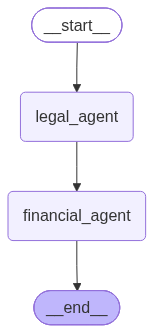

In [10]:
# Визуализация графа (опционально, но очень полезно для отладки)
# Показывает архитектуру нашего мульти-агентного пайплайна.

try:
    png_data = app.get_graph().draw_mermaid_png()
    display(Image(png_data))
except Exception as e:
    print(f"Не удалось отрисовать граф (возможно, не установлен пакет pyppeteer/graphviz): {e}")
    print("Граф успешно скомпилирован, переходим к тестам.")

## 9. Подготовка тестовых данных

In [11]:
# Подготовка тестовых данных
# Короткий, но "плохой" договор для проверки агентов.

test_contract = """
ДОГОВОР ПОСТАВКИ ОБОРУДОВАНИЯ № 123
г. Москва, 01.01.2024

ООО "Поставщик" и ООО "Покупатель" заключили настоящий договор о следующем:
1. Поставщик обязуется передать оборудование, а Покупатель принять и оплатить.
2. Стоимость оборудования составляет 1 000 000 рублей.
3. Оплата производится в течение 30 дней после поставки.
4. В случае задержки оплаты Покупатель платит штраф 1% от суммы договора за каждый день просрочки.
5. В случае задержки поставки Поставщик платит штраф 0.01% от суммы договора за каждый день.
6. Оборудование считается поставленным после того, как Покупатель начнет его использовать.
7. Споры решаются в суде по месту нахождения Истца.
"""

initial_state = {
    "contract_text": test_contract,
    "legal_review": "",
    "financial_review": ""
}

## 10. Запуск мульти-агентного графа

In [12]:
# Запуск мульти-агентного графа
print("🚀 Запуск процесса проверки договора...\n")

# invoke() запускает граф с начальным состоянием
final_state = app.invoke(initial_state)

print("\n" + "="*50)
print("✅ ПРОВЕРКА ЗАВЕРШЕНА")
print("="*50)

🚀 Запуск процесса проверки договора...

⚖️ [Агент-юрист] Начинаю анализ договора...
⚖️ [Агент-юрист] Анализ завершен.
💰 [Агент-финансист] Начинаю анализ договора...
💰 [Агент-финансист] Анализ завершен.

✅ ПРОВЕРКА ЗАВЕРШЕНА


## 11. Вывод результатов работы агентов

In [13]:
# Вывод результатов работы агентов
print("\n📜 ОТЧЕТ АГЕНТА-ЮРИСТА:")
print("-" * 30)
print(final_state["legal_review"])

print("\n\n💼 ОТЧЕТ АГЕНТА-ФИНАНСИСТА:")
print("-" * 30)
print(final_state["financial_review"])


📜 ОТЧЕТ АГЕНТА-ЮРИСТА:
------------------------------
## Анализ текста договора и выявление ключевых юридических рисков

### 1. Отсутствие существенных условий договора

- **Неопределенность относительно наименования и характеристик оборудования**:  
  Договор содержит лишь общее указание на обязательство поставщика поставить оборудование и покупателя принять его, однако отсутствует конкретизация наименований, моделей, технических характеристик и иных важных деталей оборудования (например, ГОСТ, ТУ, маркировка). Это создает риск возникновения споров между сторонами относительно качества и количества товара.

- **Отсутствие сроков поставки**:  
  В тексте указано, что оборудование передается после начала его использования покупателем, однако конкретный срок передачи оборудования не установлен. Это ведет к неопределенности относительно момента исполнения обязательства поставщиком и увеличивает вероятность конфликта сторон.

### 2. Двусмысленные формулировки и неясности

- **Формулировка